**STUDENT MENTAL HEALTH**

In [ ]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 

In [1]:
from sklearn import metrics
from sklearn.metrics import classification_report 

**data loading**

In [6]:
df = pd.read_csv('c:/Users/aqib farooq/Downloads/python_daily_tasks/student_mental_health_burnout.csv')
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low
149996,249997,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High
149997,249998,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High
149998,249999,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium


In [ ]:
#onehot encoding method kesy implement krty or khn
import pandas as pd
df = pd.read_csv('c:/Users/aqib farooq/Downloads/python_daily_tasks/student_mental_health_burnout.csv')
df = pd.get_dummies(df,columns=['gender'] , dtype=str)
df

,student_id,age,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,...,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level,gender_Female,gender_Male,gender_Other
0,100001,23,BTech,1st,4.3,6.8,6.1,High,10,3,...,6,1.8,Average,66.5,9.63,Good,High,False,True,False
1,100002,20,BTech,3rd,1.4,4.7,3.0,High,2,10,...,9,1.9,Poor,55.8,6.04,Poor,Low,False,True,False
2,100003,24,BCA,4th,3.7,4.8,1.5,Low,2,7,...,3,0.8,Good,85.0,8.31,Good,High,True,False,False
3,100004,21,BSc,4th,1.6,6.7,7.0,High,3,3,...,9,0.7,Poor,89.1,5.95,Good,High,False,True,False
4,100005,23,BSc,4th,2.0,6.7,5.4,High,7,7,...,4,1.7,Good,58.7,8.51,Good,Low,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,BSc,3rd,1.6,8.2,11.3,Medium,9,9,...,10,2.0,Good,54.2,7.82,Good,Low,True,False,False
149996,249997,25,BCA,3rd,9.9,4.8,1.6,High,10,3,...,2,0.1,Poor,53.6,7.19,Average,High,False,True,False
149997,249998,22,BTech,1st,1.4,4.4,4.6,High,10,8,...,7,1.6,Good,90.7,9.78,Average,High,False,True,False
149998,249999,19,BSc,3rd,1.5,4.3,1.1,Medium,8,6,...,4,1.1,Average,83.9,9.88,Average,Medium,False,True,False


**SECTION 1 DATA UNDERSTANDING**

#Q1 How many rows and columns are present in the dataset? Based on the sample provided, 
what is the total number of unique students? 

In [7]:
df.shape

(150000, 20)

Q2 Which columns have missing values? Examine the provided sample are there any visible 
missing entries? How would you systematically check for missing values across the 
entire dataset?

In [ ]:
#there is no null values in this dataset
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

Q3 Identify all categorical, numerical, and ordinal columns in the dataset. Justify your 
classification for each. 

In [14]:
#categorical
categorical_col = df.select_dtypes(include=['object' , 'string'])
categorical_col


,gender,course,year,stress_level,sleep_quality,internet_quality,burnout_level
0,Male,BTech,1st,High,Average,Good,High
1,Male,BTech,3rd,High,Poor,Poor,Low
2,Female,BCA,4th,Low,Good,Good,High
3,Male,BSc,4th,High,Poor,Good,High
4,Other,BSc,4th,High,Good,Good,Low
...,...,...,...,...,...,...,...
149995,Female,BSc,3rd,Medium,Good,Good,Low
149996,Male,BCA,3rd,High,Poor,Average,High
149997,Male,BTech,1st,High,Good,Average,High
149998,Male,BSc,3rd,Medium,Average,Average,Medium


In [15]:
#numerical
numerical_col = df.select_dtypes(include=['integer'])
numerical_col

,student_id,age,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score
0,100001,23,10,3,4,2,6
1,100002,20,2,10,8,5,9
2,100003,24,2,7,8,6,3
3,100004,21,3,3,4,9,9
4,100005,23,7,7,6,4,4
...,...,...,...,...,...,...,...
149995,249996,24,9,9,5,3,10
149996,249997,25,10,3,10,10,2
149997,249998,22,10,8,6,4,7
149998,249999,19,8,6,5,7,4


In [31]:
#ordinal col
ordinal_col =(['year','stress_level','sleep_quality','internet_quality','burnout_level'])
ordinal_col

['year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']

Q4 Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and 
screen_time_hours.

In [37]:
mean_cgpa = df['cgpa'].mean
mean_daily_study_hours = df['daily_study_hours'].mean
screen_time_hours = df['screen_time_hours'].mean
print(f"mean_cgpa:{mean_cgpa}")
print(f"mean_daily_study_hours:{mean_daily_study_hours}")
print(f"screen_time_hours:{screen_time_hours}")

mean_cgpa:<bound method Series.mean of 0         9.63
1         6.04
2         8.31
3         5.95
4         8.51
          ... 
149995    7.82
149996    7.19
149997    9.78
149998    9.88
149999    7.00
Name: cgpa, Length: 150000, dtype: float64>
mean_daily_study_hours:<bound method Series.mean of 0         4.3
1         1.4
2         3.7
3         1.6
4         2.0
         ... 
149995    1.6
149996    9.9
149997    1.4
149998    1.5
149999    3.7
Name: daily_study_hours, Length: 150000, dtype: float64>
screen_time_hours:<bound method Series.mean of 0          6.1
1          3.0
2          1.5
3          7.0
4          5.4
          ... 
149995    11.3
149996     1.6
149997     4.6
149998     1.1
149999     2.6
Name: screen_time_hours, Length: 150000, dtype: float64>


In [38]:
median_cgpa = df['cgpa'].median
median_daily_study_hours = df['daily_study_hours'].median
median_screen_time_hours = df['screen_time_hours'].median

print(f"median_cgpa:{median_cgpa}")
print(f"median_daily_study_hours:{mean_daily_study_hours}")
print(f"median_screen_time_hours:{median_screen_time_hours}")

median_cgpa:<bound method Series.median of 0         9.63
1         6.04
2         8.31
3         5.95
4         8.51
          ... 
149995    7.82
149996    7.19
149997    9.78
149998    9.88
149999    7.00
Name: cgpa, Length: 150000, dtype: float64>
median_daily_study_hours:<bound method Series.mean of 0         4.3
1         1.4
2         3.7
3         1.6
4         2.0
         ... 
149995    1.6
149996    9.9
149997    1.4
149998    1.5
149999    3.7
Name: daily_study_hours, Length: 150000, dtype: float64>
median_screen_time_hours:<bound method Series.median of 0          6.1
1          3.0
2          1.5
3          7.0
4          5.4
          ... 
149995    11.3
149996     1.6
149997     4.6
149998     1.1
149999     2.6
Name: screen_time_hours, Length: 150000, dtype: float64>


In [41]:
std_cgpa = df['cgpa'].std()
std_daily_study_hours = df['daily_study_hours'].std()
std_screen_time_hours = df['screen_time_hours'].std()

print(f"std_cgpa:{std_cgpa}")
print(f"std_daily_study_hours:{std_daily_study_hours}")
print(f"std_screen_time_hours:{std_screen_time_hours}")

std_cgpa:1.7321799909350664
std_daily_study_hours:2.5955918781785035
std_screen_time_hours:3.178948236357242


Q5 Which gender has the highest average anxiety_score? Provide the exact value.

In [42]:

gender_anxiety = df.groupby('gender')['anxiety_score'].mean()


highest_gender = gender_anxiety.idxmax()
highest_value = gender_anxiety.max()

print("Average Anxiety Score by Gender:")
print(gender_anxiety)
print(f"\nResult: {highest_gender} has the highest average anxiety score of {highest_value:.6f}")

Average Anxiety Score by Gender:
gender
Female    5.488237
Male      5.502862
Other     5.490629
Name: anxiety_score, dtype: float64

Result: Male has the highest average anxiety score of 5.502862


Q6 List all unique course values and calculate the proportion of students in each course. 

In [48]:
unique_courses = df['course'].unique()
print(unique_courses)

<StringArray>
['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA']
Length: 6, dtype: str


In [49]:
count=df.groupby('course')['student_id'].count()
count

course
BBA      25103
BCA      24973
BSc      24894
BTech    24849
MBA      25231
MCA      24950
Name: student_id, dtype: int64

In [50]:
total = df.shape[0]  # total number of rows (students)
print(total)

150000


In [51]:
percentage=total/count*100
percentage

course
BBA      597.538143
BCA      600.648701
BSc      602.554832
BTech    603.646022
MBA      594.506758
MCA      601.202405
Name: student_id, dtype: float64

In [2]:
# Pie chart
import matplotlib.pyplot as plt


plt.figure(figsize=(7,7))
plt.pie(percentage, 
        labels=percentage.index,     # slice labels
        autopct='%1.1f%%',             # percentage display
        startangle=90,                  # rotate chart
        colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])  # custom colors
plt.title("all unique course values and calculate the proportion of students in each course. ")
plt.show()

NameError: name 'percentage' is not defined

<Figure size 700x700 with 0 Axes>

Q7 What is the distribution of year of study? How many students are in each academic 
year? 

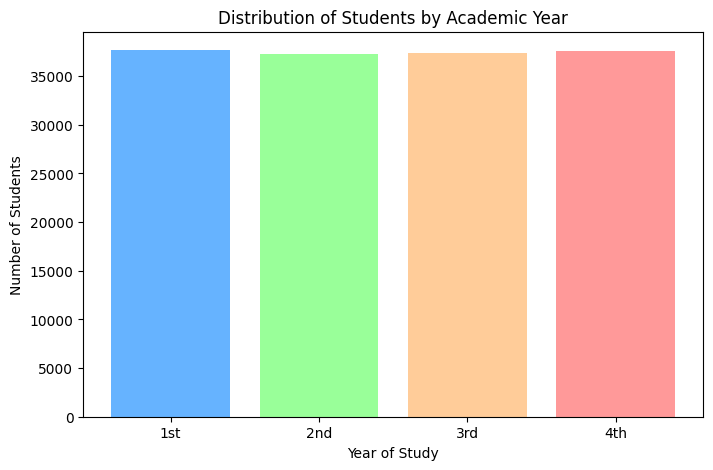

In [58]:
import pandas as pd
import matplotlib.pyplot as plt


# 'year' column ki values ko count karein
year_counts = df['year'].value_counts().sort_index()

# Chart ka size set karein
plt.figure(figsize=(8,5))

# Bar chart banayein
plt.bar(year_counts.index, year_counts.values, 
        color=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])

# Labels aur Title lagayien
plt.title("Distribution of Students by Academic Year")
plt.xlabel("Year of Study")
plt.ylabel("Number of Students")

# Chart ko save karein
plt.savefig('year_distribution.png')

Q8 Compare the average cgpa between students with sleep_quality = "Good" vs "Poor". 

In [60]:
import pandas as pd

# Sleep quality ke mutabiq CGPA ka average nikalna
sleep_comparison = df.groupby('sleep_quality')['cgpa'].mean()

# "Good" aur "Poor" sleep ka result nikalna
avg_good = sleep_comparison['Good']
avg_poor = sleep_comparison['Poor']

print(f"Average CGPA (Good Sleep): {avg_good:.4f}")
print(f"Average CGPA (Poor Sleep): {avg_poor:.4f}")

Average CGPA (Good Sleep): 7.0137
Average CGPA (Poor Sleep): 6.9872


Q9 What is the correlation between daily_study_hours and cgpa in the sample? 

In [61]:
# Correlation calculate karna
correlation = df[['daily_study_hours', 'cgpa']].corr().iloc[0, 1]

print(f"Correlation between Study Hours and CGPA: {correlation:.4f}")

Correlation between Study Hours and CGPA: -0.0054


Q10 Which stress_level category appears most frequently, and what is its percentage?

In [62]:
# Sabse zyada frequency wala stress level nikalna
stress_counts = df['stress_level'].value_counts()
most_freq_stress = stress_counts.idxmax()

# Percentage nikalna
total_students = len(df)
percentage = (stress_counts.max() / total_students) * 100

print(f"Most Frequent Stress Level: {most_freq_stress}")
print(f"Percentage: {percentage:.2f}%")

Most Frequent Stress Level: High
Percentage: 33.53%


SECTION2 DATA CLEANING AND PROCESSING

Missing Value Handling 

a. How many rows contain at least one NaN value? 
b. If missing values exist, what strategies would you use for numerical columns vs categorical 
columns? Provide at least two different imputation methods for each type with justification. 
c. Are there any rows with all NaN values? How would you handle them? 

In [72]:
import pandas as pd


#Check total rows with at least one NaN
rows_with_nan = df.isnull().sum()
rows_with_nan



student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [71]:
df[df.isnull().all(axis=1)]


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level


In [73]:
#Check column-wise missing values
missing_info = df.isnull().sum()

print(f"Total rows with NaN: {rows_with_nan}")
print("\nMissing values in each column:")
print(missing_info)

Total rows with NaN: student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

Missing values in each column:
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financ

DUPLICATE DETECTION

How many duplicate rows exist? What columns would you consider to define a duplicate 
record? 
b. If duplicates are found, what effect might keeping them have on logistic regression model 
performance?

In [76]:
df.duplicated().sum()

np.int64(0)

OUTLIER DETECTION AND TREATMENT

Use the IQR method to detect outliers. How many outliers exist in each? 

In [77]:
import pandas as pd

# Numerical columns list
numerical_cols = [
    'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 
    'anxiety_score', 'depression_score', 'academic_pressure_score', 
    'financial_stress_score', 'social_support_score', 'physical_activity_hours', 
    'attendance_percentage', 'cgpa'
]

# IQR detection loop
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in age: 0
Outliers in daily_study_hours: 0
Outliers in daily_sleep_hours: 0
Outliers in screen_time_hours: 0
Outliers in anxiety_score: 0
Outliers in depression_score: 0
Outliers in academic_pressure_score: 0
Outliers in financial_stress_score: 0
Outliers in social_support_score: 0
Outliers in physical_activity_hours: 0
Outliers in attendance_percentage: 0
Outliers in cgpa: 0


 Apply two different outlier treatment methods (iqr and transformation) and explain which you 
would choose for logistic regression and why. 

In [78]:
# IQR Capping Code
# Maan lijiye hum CGPA par apply kar rahe hain
Q1 = df['cgpa'].quantile(0.25)
Q3 = df['cgpa'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Capping (replace values outside limits)
df['cgpa_capped'] = df['cgpa'].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
import numpy as np
# Log transformation (Adding 1 to avoid log(0))
df['cgpa_log'] = np.log1p(df['cgpa'])

#sb stable hy

**Encoding Categorical Variables **

a. Identify all categorical columns and explain why they need encoding. 

In [5]:
import pandas as pd
import pandas as pd

# Data load karein
df = pd.read_csv('student_mental_health_burnout.csv')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Ye columns Categorical hain:")
print(cat_cols)

Ye columns Categorical hain:
['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']


C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_5408\3893100391.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


b. Apply both One-Hot Encoding and Label Encoding to appropriate columns. Compare the 
results. 

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Dataset load karein
df = pd.read_csv('student_mental_health_burnout.csv')

# --- PART A: One-Hot Encoding (OHE) ---
# Ye un columns ke liye behtar hai jin mein koi order (rank) nahi hota (Nominal).
# Example: Gender, Course
df_ohe = pd.get_dummies(df[['gender', 'course']], prefix=['gender', 'course'])

# --- PART B: Label Encoding (LE) ---
# Ye un columns ke liye use hota hai jin mein ek khaas tarteeb hoti hai (Ordinal).
# Example: Stress Level (Low < Medium < High)
le = LabelEncoder()
df_le = df[['stress_level', 'sleep_quality', 'year']].copy()

for col in ['stress_level', 'sleep_quality', 'year']:
    df_le[col + '_encoded'] = le.fit_transform(df_le[col])

# --- Result Comparison ---
print("--- One-Hot Encoding Result (Dimensionality Expansion) ---")
print(df_ohe.head(3))

print("\n--- Label Encoding Result (Integer Assignment) ---")
print(df_le[['stress_level_encoded', 'sleep_quality_encoded', 'year_encoded']].head(3))

--- One-Hot Encoding Result (Dimensionality Expansion) ---
   gender_Female  gender_Male  gender_Other  course_BBA  course_BCA  \
0          False         True         False       False       False   
1          False         True         False       False       False   
2           True        False         False       False        True   

   course_BSc  course_BTech  course_MBA  course_MCA  
0       False          True       False       False  
1       False          True       False       False  
2       False         False       False       False  

--- Label Encoding Result (Integer Assignment) ---
   stress_level_encoded  sleep_quality_encoded  year_encoded
0                     0                      0             0
1                     0                      2             2
2                     1                      1             3


For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High), why is 
ordinal encoding more appropriate than one-hot encoding? Implement it.

In [7]:
import pandas as pd


# 2. Manual Mappings 
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
sleep_map = {'Poor': 0, 'Average': 1, 'Good': 2}

# 3. Apply Mappings to the columns
df['stress_level_encoded'] = df['stress_level'].map(stress_map)
df['sleep_quality_encoded'] = df['sleep_quality'].map(sleep_map)

# 4. Result check karein
print("--- Ordinal Encoding Result ---")
print(df[['stress_level', 'stress_level_encoded', 'sleep_quality', 'sleep_quality_encoded']].head(10))

# 5. Verification (Check if any NaN created due to wrong mapping)
print("\nAny missing values after mapping?:", df[['stress_level_encoded', 'sleep_quality_encoded']].isnull().sum().sum())

--- Ordinal Encoding Result ---
  stress_level  stress_level_encoded sleep_quality  sleep_quality_encoded
0         High                     2       Average                      1
1         High                     2          Poor                      0
2          Low                     0          Good                      2
3         High                     2          Poor                      0
4         High                     2          Good                      2
5         High                     2          Poor                      0
6          Low                     0       Average                      1
7       Medium                     1          Poor                      0
8          Low                     0       Average                      1
9       Medium                     1          Poor                      0

Any missing values after mapping?: 0


Feature Scaling 

Apply StandardScaler to all numerical features. Show the mean and standard deviation of 
scaled features to verify. 

In [33]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('student_mental_health_burnout.csv')

# numerical columns list
numerical_cols = [
    'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 
    'anxiety_score', 'depression_score', 'academic_pressure_score', 
    'financial_stress_score', 'social_support_score', 'physical_activity_hours', 
    'attendance_percentage', 'cgpa'
]

# 3. StandardScaler apply
scaler = StandardScaler()
df_scaled = df.copy() # for original data safe
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 4. Verification: Mean aur Standard Deviation check
verification_stats = df_scaled[numerical_cols].agg(['mean', 'std']).round(2)

print("--- Verification Results (Scaled Features) ---")
print(verification_stats)

--- Verification Results (Scaled Features) ---
      age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
mean  0.0               -0.0                0.0                0.0   
std   1.0                1.0                1.0                1.0   

      anxiety_score  depression_score  academic_pressure_score  \
mean           -0.0               0.0                      0.0   
std             1.0               1.0                      1.0   

      financial_stress_score  social_support_score  physical_activity_hours  \
mean                     0.0                  -0.0                      0.0   
std                      1.0                   1.0                      1.0   

      attendance_percentage  cgpa  
mean                    0.0  -0.0  
std                     1.0   1.0  


Data Type Validation 

After preprocessing, verify that all columns have appropriate data types for modeling. Convert 
any incorrectly typed columns. 

In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('student_mental_health_burnout.csv')

# --- STEP A: Encoding (Categorical to Numerical) ---

# i. One-Hot Encoding (Nominal columns: Gender, Course)
df_processed = pd.get_dummies(df, columns=['gender', 'course'], drop_first=True)

# ii. Ordinal Mapping (Ranked columns: Stress, Sleep, Year, Burnout)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
sleep_map = {'Poor': 0, 'Average': 1, 'Good': 2}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
year_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
burnout_map = {'Low': 0, 'Medium': 1, 'High': 2}

df_processed['stress_level'] = df_processed['stress_level'].map(stress_map)
df_processed['sleep_quality'] = df_processed['sleep_quality'].map(sleep_map)
df_processed['internet_quality'] = df_processed['internet_quality'].map(internet_map)
df_processed['year'] = df_processed['year'].map(year_map)
df_processed['burnout_level'] = df_processed['burnout_level'].map(burnout_map)

# --- STEP B: Feature Scaling (Standardization) ---

# Numerical columns ki list
num_cols = [
    'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 
    'anxiety_score', 'depression_score', 'academic_pressure_score', 
    'financial_stress_score', 'social_support_score', 'physical_activity_hours', 
    'attendance_percentage', 'cgpa'
]

scaler = StandardScaler()
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])

# --- STEP C: Final Data Type Verification & Conversion ---

df_final = df_processed.astype(float)

# Verification check 
print("--- Final Data Types (Should all be float64) ---")
print(df_final.dtypes.unique())

print("\n--- Final Data Sample (Top 5 rows) ---")
print(df_final.head())

# Check for any Missing Values (NaNs)
print("\nMissing Values Count:", df_final.isnull().sum().sum())

--- Final Data Types (Should all be float64) ---
[dtype('float64')]

--- Final Data Sample (Top 5 rows) ---
   student_id       age  year  daily_study_hours  daily_sleep_hours  \
0    100001.0  0.774684   1.0          -0.465355           0.208220   
1    100002.0 -0.387563   3.0          -1.582638          -1.246221   
2    100003.0  1.162099   4.0          -0.696517          -1.176962   
3    100004.0 -0.000147   4.0          -1.505584           0.138960   
4    100005.0  0.774684   4.0          -1.351476           0.138960   

   screen_time_hours  stress_level  anxiety_score  depression_score  \
0          -0.126715           2.0       1.568648         -0.870460   
1          -1.101884           2.0      -1.216288          1.569404   
2          -1.573739           0.0      -1.216288          0.523748   
3           0.156398           2.0      -0.868171         -0.870460   
4          -0.346914           2.0       0.524297          0.523748   

   academic_pressure_score  ...      c

**Section 3: Exploratory Data Analysis (EDA) **

Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and 
kurtosis. 

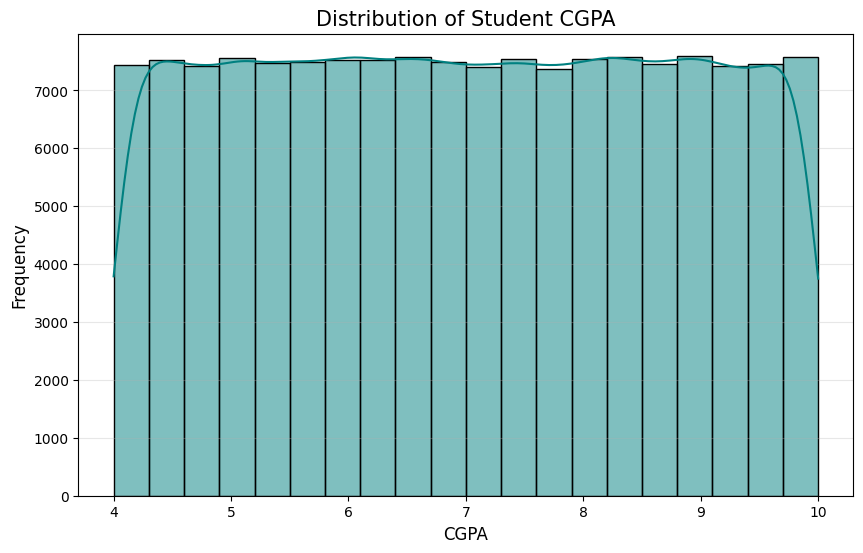

--- CGPA Distribution Stats ---
Mean CGPA: 7.00
Median CGPA: 6.99
Skewness: 0.0013
Kurtosis: -1.1994


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Visualization (Histogram aur KDE Plot)
plt.figure(figsize=(10, 6))
sns.histplot(df['cgpa'], kde=True, color='teal', bins=20)

# Labels aur Title
plt.title('Distribution of Student CGPA', fontsize=15)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Plot save karein
plt.savefig('cgpa_distribution_plot.png')
plt.show()

# 3. Statistics (Skewness aur Kurtosis) calculate karein
cgpa_skew = skew(df['cgpa'])
cgpa_kurt = kurtosis(df['cgpa']) # Excess Kurtosis (Normal = 0)

print(f"--- CGPA Distribution Stats ---")
print(f"Mean CGPA: {df['cgpa'].mean():.2f}")
print(f"Median CGPA: {df['cgpa'].median():.2f}")
print(f"Skewness: {cgpa_skew:.4f}")
print(f"Kurtosis: {cgpa_kurt:.4f}")

Plot a boxplot of cgpa by stress_level. What insights can you derive about the 
relationship between stress and academic performance? 

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_5408\843938145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y='cgpa', data=df,


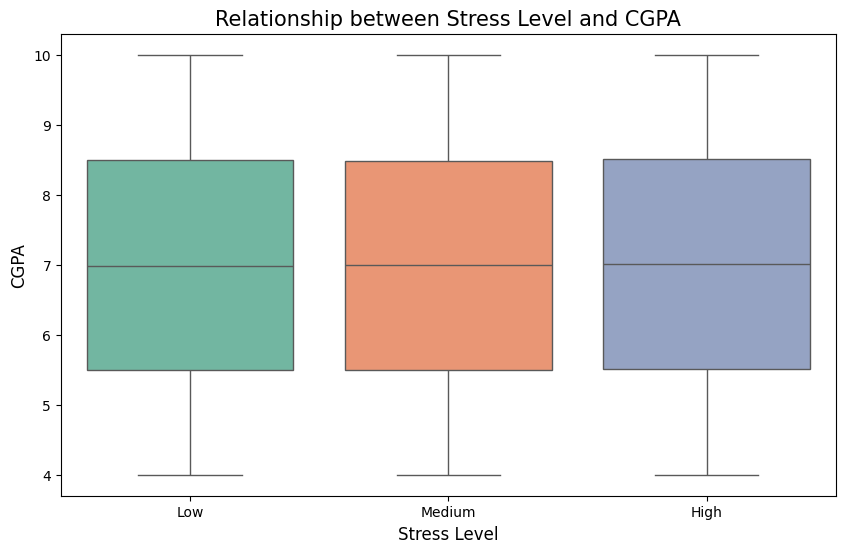

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Boxplot create 
plt.figure(figsize=(10, 6))
# Order specify  (Low -> Medium -> High)
sns.boxplot(x='stress_level', y='cgpa', data=df, 
            order=['Low', 'Medium', 'High'], 
            palette='Set2')

# Labels aur Title
plt.title('Relationship between Stress Level and CGPA', fontsize=15)
# X aur Y labels
plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('CGPA', fontsize=12)

# Plot save 
plt.savefig('stress_vs_cgpa_boxplot.png')
plt.show()

Create a bar plot showing average anxiety_score by gender. Which gender shows 
higher anxiety, and does this align with common expectations? 

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_5408\1101558971.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_anxiety.index, y=gender_anxiety.values, palette='viridis')


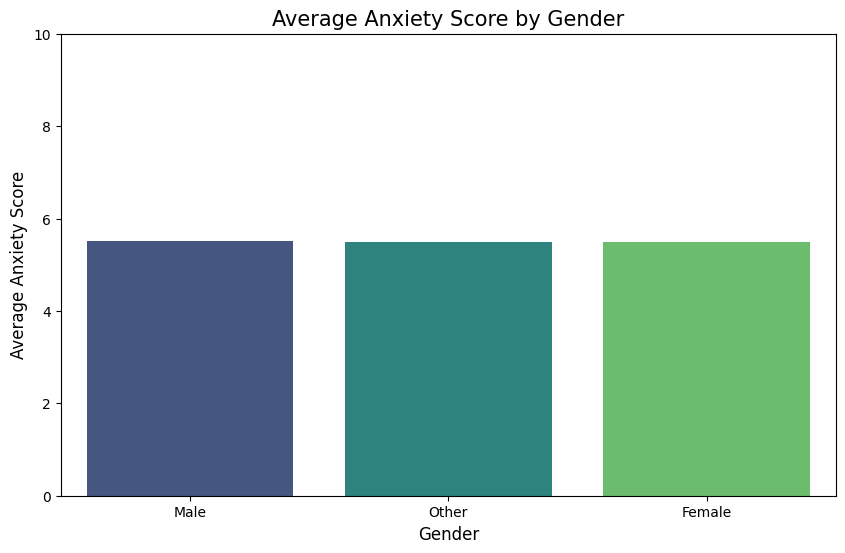

Average Anxiety Scores:
gender
Male      5.502862
Other     5.490629
Female    5.488237
Name: anxiety_score, dtype: float64


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Gender wise average anxiety calculate
gender_anxiety = df.groupby('gender')['anxiety_score'].mean().sort_values(ascending=False)

# 3. Bar Plot create 
plt.figure(figsize=(10, 6))
sns.barplot(x=gender_anxiety.index, y=gender_anxiety.values, palette='viridis')

# Labels aur Title
plt.title('Average Anxiety Score by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Anxiety Score', fontsize=12)
plt.ylim(0, 10) # Score 0 se 10 ke darmiyan hai

# Plot save
plt.savefig('anxiety_by_gender.png')
plt.show()

print("Average Anxiety Scores:")
print(gender_anxiety)

Plot a scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by 
sleep_quality. What patterns emerge? 

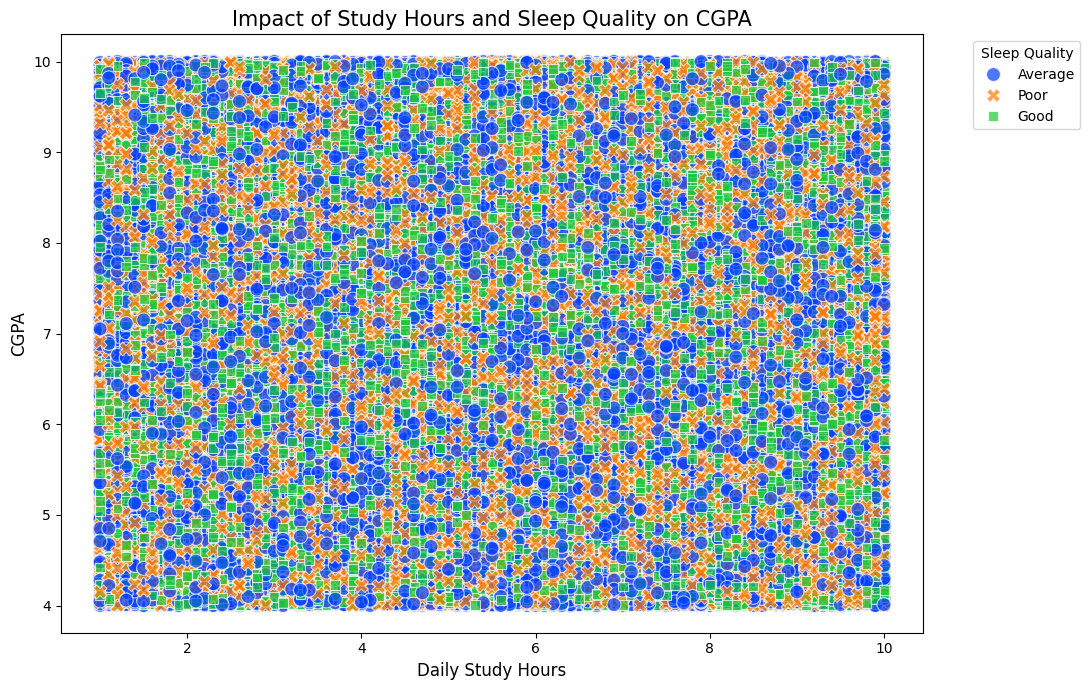

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Scatter Plot create 
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x='daily_study_hours', y='cgpa', 
                hue='sleep_quality', 
                style='sleep_quality', 
                palette='bright', 
                alpha=0.7, s=100)

# Labels aur Title
plt.title('Impact of Study Hours and Sleep Quality on CGPA', fontsize=15)
plt.xlabel('Daily Study Hours', fontsize=12)
plt.ylabel('CGPA', fontsize=12)
plt.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('study_vs_cgpa_scatter.png')
plt.show()

Create a grouped bar chart showing the count of students in each burnout_level across 
different course types. Which course has the highest burnout proportion? 

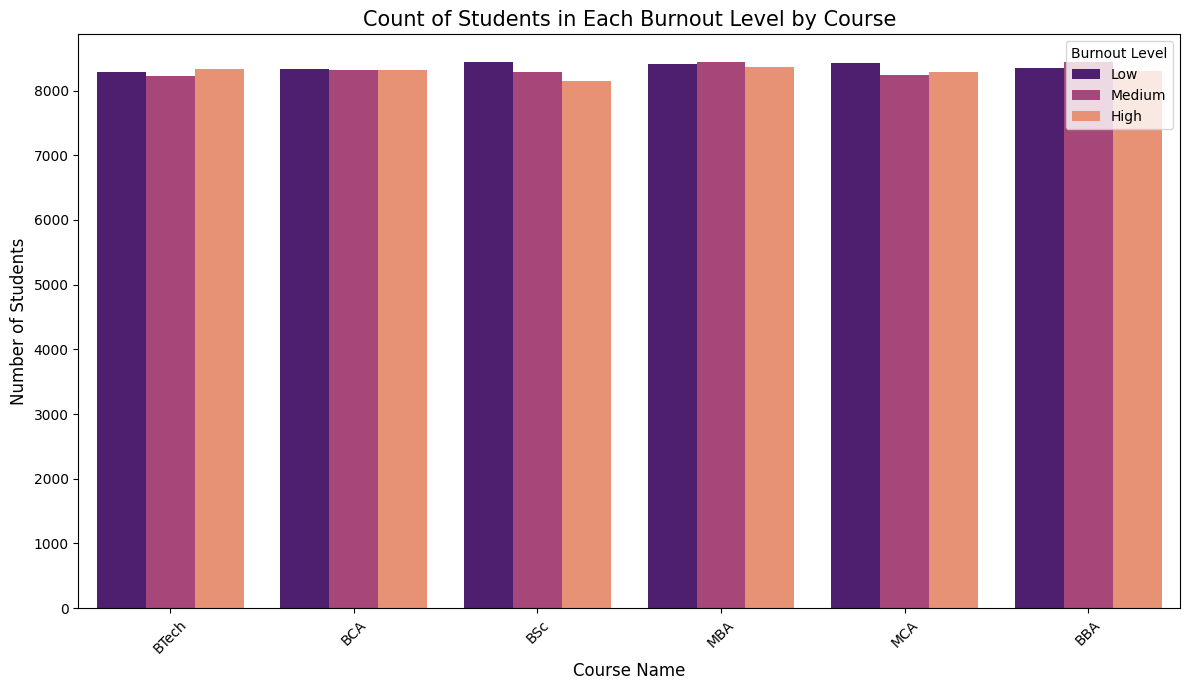

--- Burnout Proportions (%) by Course ---
course
BTech    33.526500
BCA      33.323990
MCA      33.198397
MBA      33.153660
BBA      33.099630
BSc      32.762915
Name: High, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Grouped Bar Chart create 
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='course', hue='burnout_level', 
              palette='magma', hue_order=['Low', 'Medium', 'High'])

# Labels aur Title
plt.title('Count of Students in Each Burnout Level by Course', fontsize=15)
plt.xlabel('Course Name', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=45) # Course names lambe ho sakte hain
plt.legend(title='Burnout Level')

# Plot save
plt.tight_layout()
plt.savefig('burnout_by_course.png')
plt.show()

# 3. Proportion (Percentage) 
burnout_proportions = pd.crosstab(df['course'], df['burnout_level'], normalize='index') * 100
print("--- Burnout Proportions (%) by Course ---")
print(burnout_proportions['High'].sort_values(ascending=False))

Plot the distribution of screen_time_hours. Identify any extreme values and relate them 
to depression_score. 

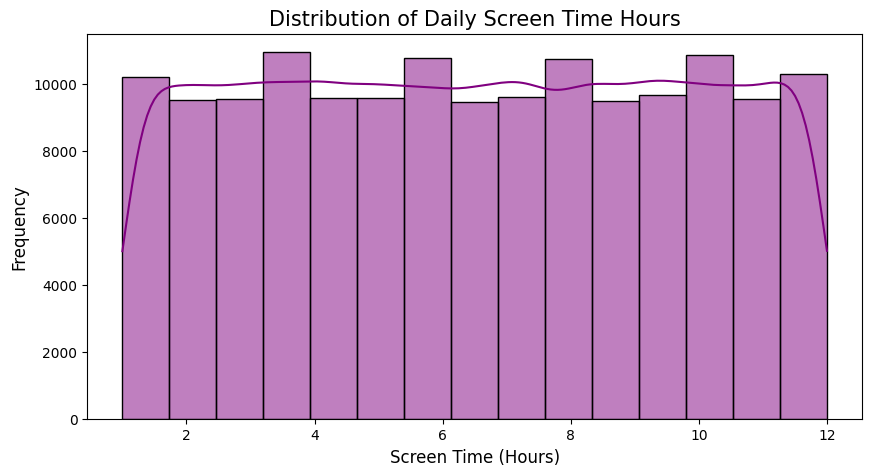

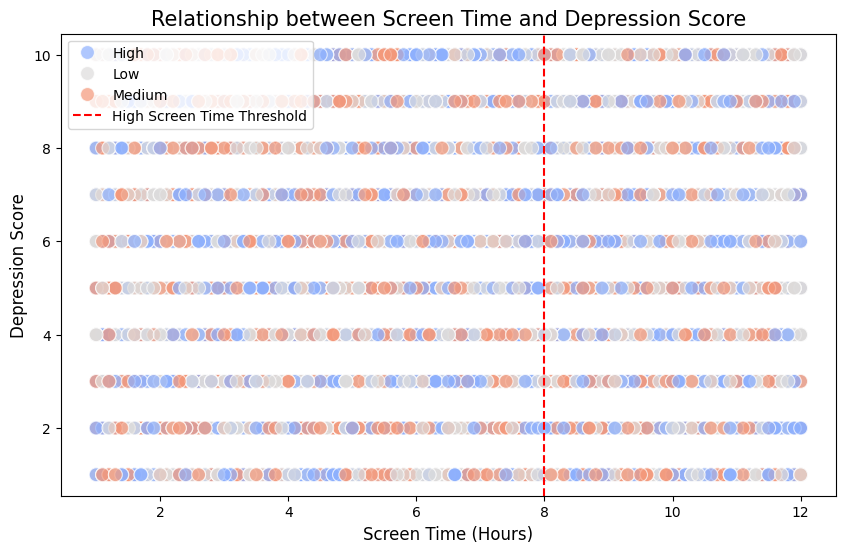

Correlation between Screen Time and Depression: 0.0026


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Dataset load karein
df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Distribution Plot for Screen Time
plt.figure(figsize=(10, 5))
sns.histplot(df['screen_time_hours'], kde=True, color='purple', bins=15)
plt.title('Distribution of Daily Screen Time Hours', fontsize=15)
plt.xlabel('Screen Time (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig('screen_time_dist.png')
plt.show()

# 3. Scatter Plot: Screen Time vs Depression Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='screen_time_hours', y='depression_score', data=df, 
                hue='stress_level', palette='coolwarm', s=100, alpha=0.7)

# Extreme values identify karne ke liye reference line (e.g., > 8 hours)
plt.axvline(x=8, color='red', linestyle='--', label='High Screen Time Threshold')

plt.title('Relationship between Screen Time and Depression Score', fontsize=15)
plt.xlabel('Screen Time (Hours)', fontsize=12)
plt.ylabel('Depression Score', fontsize=12)
plt.legend()
plt.savefig('screen_time_vs_depression.png')
plt.show()

# 4. Correlation check
correlation = df['screen_time_hours'].corr(df['depression_score'])
print(f"Correlation between Screen Time and Depression: {correlation:.4f}")

Create a violin plot of cgpa by internet_quality. What does this suggest about internet 
quality's impact on academics? 

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_5408\248134816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='internet_quality', y='cgpa', data=df,


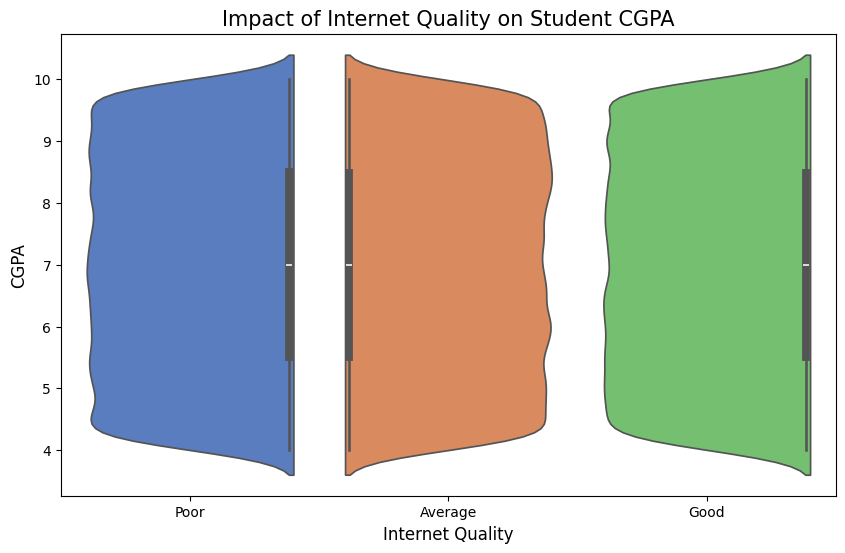

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Violin Plot create
plt.figure(figsize=(10, 6))
sns.violinplot(x='internet_quality', y='cgpa', data=df, 
               order=['Poor', 'Average', 'Good'], 
               palette='muted', split=True)

# Labels aur Title
plt.title('Impact of Internet Quality on Student CGPA', fontsize=15)
plt.xlabel('Internet Quality', fontsize=12)
plt.ylabel('CGPA', fontsize=12)

plt.savefig('internet_vs_cgpa_violin.png')
plt.show()

Plot a heatmap of the correlation matrix for all numerical variables. Which features are 
most correlated with cgpa? With anxiety_score? 

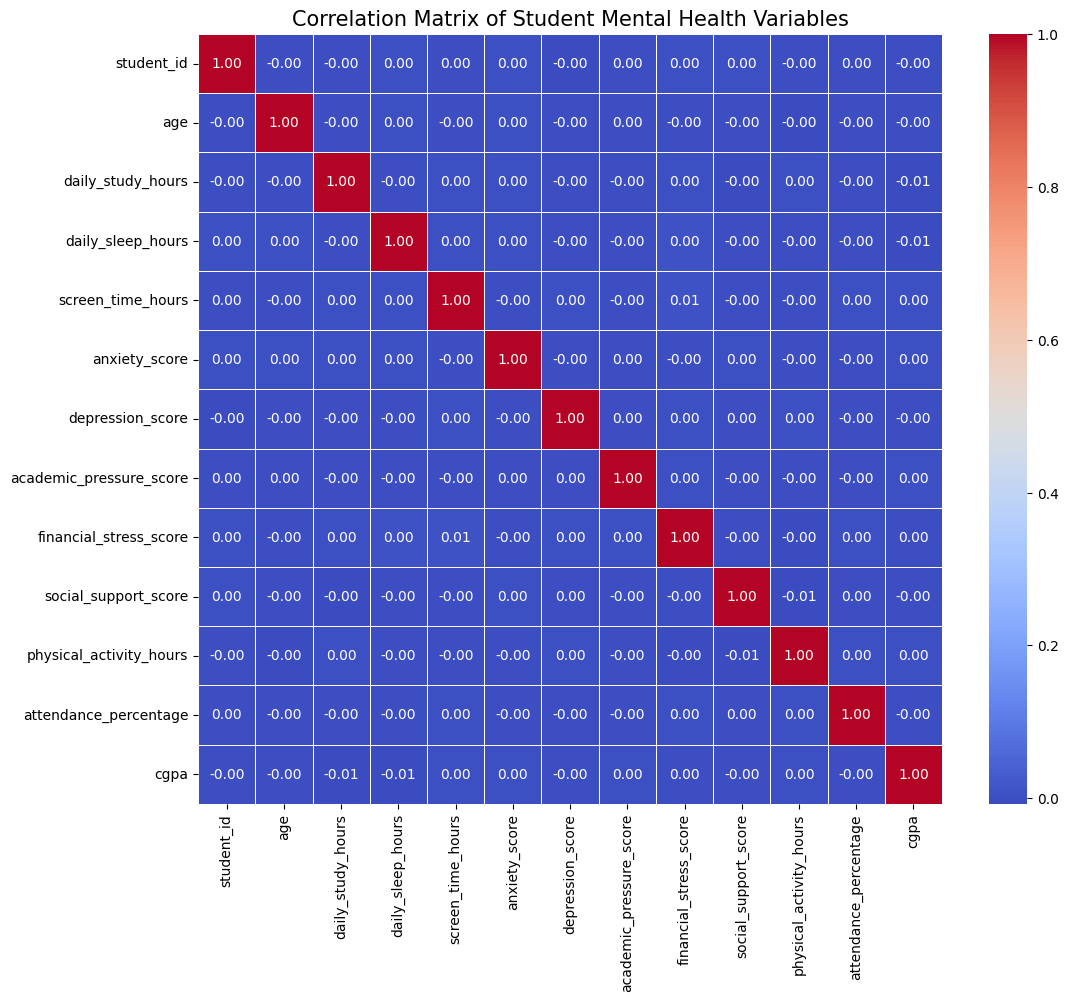

--- Correlation with CGPA ---
cgpa                       1.000000
screen_time_hours          0.002744
physical_activity_hours    0.002510
academic_pressure_score    0.001213
anxiety_score              0.001136
financial_stress_score     0.000553
social_support_score      -0.000425
depression_score          -0.002124
attendance_percentage     -0.002254
student_id                -0.002804
age                       -0.003290
daily_sleep_hours         -0.005004
daily_study_hours         -0.005450
Name: cgpa, dtype: float64

--- Correlation with Anxiety Score ---
anxiety_score              1.000000
student_id                 0.003988
daily_sleep_hours          0.003168
social_support_score       0.002810
daily_study_hours          0.002771
age                        0.001606
cgpa                       0.001136
academic_pressure_score    0.000503
attendance_percentage     -0.000118
screen_time_hours         -0.000441
financial_stress_score    -0.001421
physical_activity_hours   -0.001478
dep

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Sirf numerical variables select 

numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 3. Correlation matrix calculate 
corr_matrix = numeric_df.corr()

# 4. Heatmap plot 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Student Mental Health Variables', fontsize=15)
plt.savefig('correlation_heatmap.png')
plt.show()

# 5. Top correlations find karein
print("--- Correlation with CGPA ---")
print(corr_matrix['cgpa'].sort_values(ascending=False))

print("\n--- Correlation with Anxiety Score ---")
print(corr_matrix['anxiety_score'].sort_values(ascending=False))

Create a pairplot for daily_study_hours, screen_time_hours, cgpa, and 
anxiety_score. Which relationships appear non-linear? 

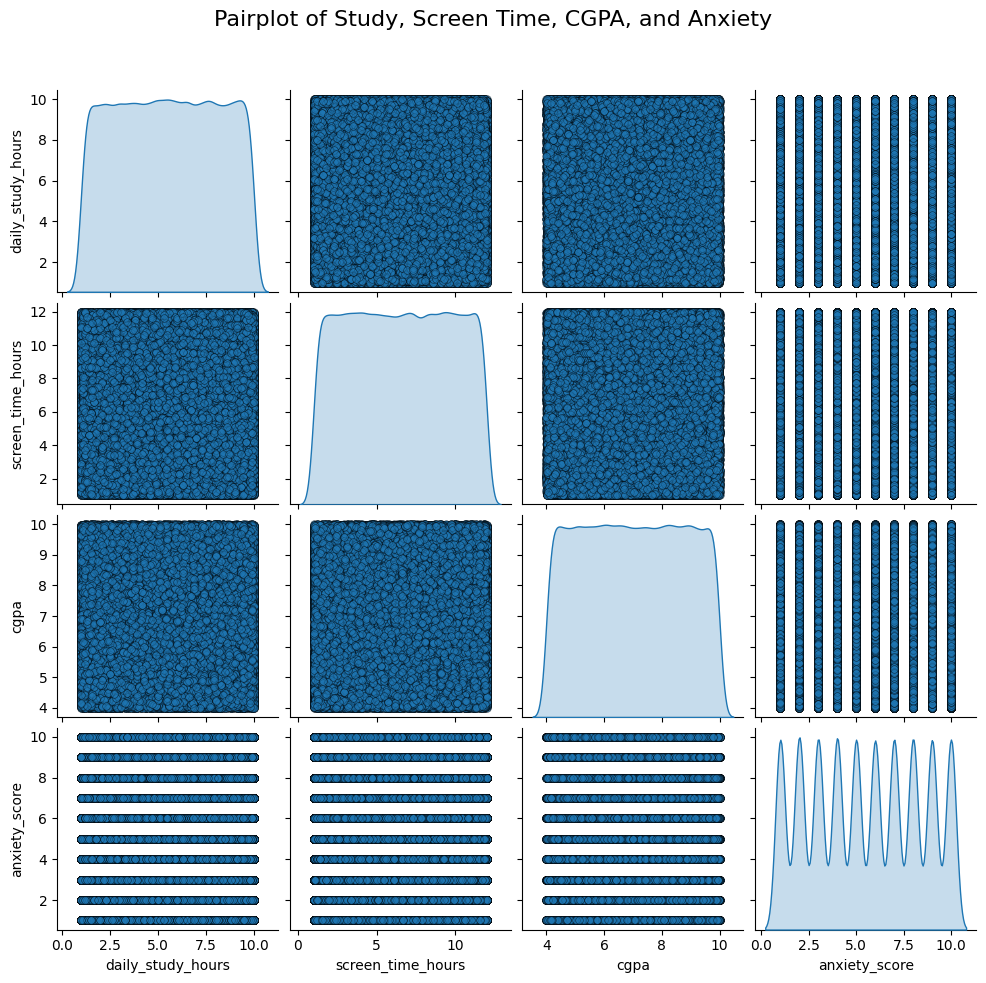

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Sirf required columns select 
selected_cols = ['daily_study_hours', 'screen_time_hours', 'cgpa', 'anxiety_score']
df_subset = df[selected_cols]

# 3. Pairplot create
# 'diag_kind' histogram dikhaye ga aur baqi scatter plots
sns.pairplot(df_subset, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})

# Title adjust 
plt.subplots_adjust(top=0.9)
plt.suptitle('Pairplot of Study, Screen Time, CGPA, and Anxiety', fontsize=16)

plt.savefig('variables_pairplot.png')
plt.show()

Boxplot of academic_pressure_score by burnout_level. Is there a statistically 
significant difference visible? 

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_5408\1066085234.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df,


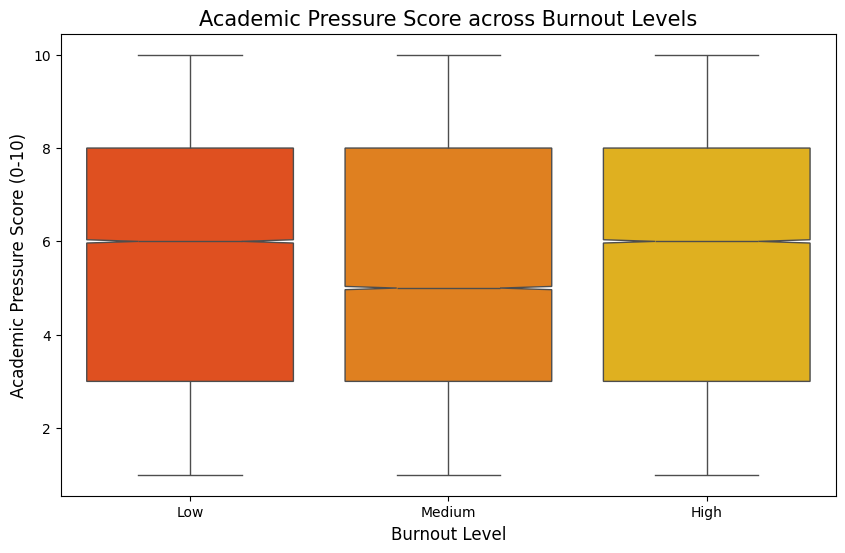

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Boxplot create  
plt.figure(figsize=(10, 6))
sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df, 
            order=['Low', 'Medium', 'High'], 
            palette='autumn',
            notch=True) # Notch for significance 

# Labels aur Title
plt.title('Academic Pressure Score across Burnout Levels', fontsize=15)
plt.xlabel('Burnout Level', fontsize=12)
plt.ylabel('Academic Pressure Score (0-10)', fontsize=12)

plt.savefig('pressure_vs_burnout_boxplot.png')
plt.show()

**Section 4: Model Building — Binary Classification**

Target Variable Creation 
Create a binary target variable high_burnout where: 
● 1 if burnout_level = "High" 
● 0 if burnout_level = "Low" or "Medium" 
Explain why you chose this binarization. 

In [ ]:
import pandas as pd


df = pd.read_csv('student_mental_health_burnout.csv')

# 2. Binary target variable create
# 'High' ko 1 aur baqi sab ko 0 assign karna
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x == 'High' else 0)

print("Target Variable Distribution:")
print(df['high_burnout'].value_counts())


print("\nFirst 5 rows with new target:")
print(df[['burnout_level', 'high_burnout']].head())

Target Variable Distribution:
high_burnout
0    100234
1     49766
Name: count, dtype: int64

First 5 rows with new target:
  burnout_level  high_burnout
0          High             1
1           Low             0
2          High             1
3          High             1
4           Low             0


Feature Selection 
a. Which columns will you use as features (X) for prediction? Justify your selection. 
b. Which column is the target (y)? 
c. Do you need to drop any columns to prevent data leakage? Identify them.

In [ ]:
# 1. Features (X) aur Target (y) 
# Un columns ko drop karein jo irrelevant hain ya leakage k wja hain
X = df.drop(['high_burnout', 'burnout_level', 'course'], axis=1) # 'course' agar categories zyada hon
y = df['high_burnout']

# 2. Categorical variables (jaise sleep_quality) ko numbers mein
X = pd.get_dummies(X, drop_first=True)

print("Final Features for Training:")
print(X.columns.tolist())

Final Features for Training:
['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'attendance_percentage', 'cgpa', 'gender_Male', 'gender_Other', 'year_2nd', 'year_3rd', 'year_4th', 'stress_level_Low', 'stress_level_Medium', 'sleep_quality_Good', 'sleep_quality_Poor', 'internet_quality_Good', 'internet_quality_Poor']


Train-Test Split 
a. Split the data into training and testing sets with 80–20 ratio and random_state = 42. Why is 
random_state important? 
b. What is the purpose of splitting the dataset before training? 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Data Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Logistic Regression Model initialize aur train
model = LogisticRegression(max_iter=1000) # max_iter convergence ke liye zaroori hai
model.fit(X_train, y_train)

# 3. Predictions
y_pred = model.predict(X_test)

# 4. Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 66.60%

Confusion Matrix:
 [[19979     0]
 [10021     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80     19979
           1       0.00      0.00      0.00     10021

    accuracy                           0.67     30000
   macro avg       0.33      0.50      0.40     30000
weighted avg       0.44      0.67      0.53     30000



c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Model Initialization & Training 
a. Initialize a Logistic Regression model with max_iter = 1000. Why might you need to increase 
max_iter? 
b. Fit the model on the training data. What is the training accuracy score? 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Model Initialize (max_iter = 1000)
log_model = LogisticRegression(max_iter=1000)

# 2. Model ko Training Data par Fit 
log_model.fit(X_train, y_train)

# 3. Training Accuracy calculate
y_train_pred = log_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy Score: {train_accuracy * 100:.2f}%")

Training Accuracy Score: 66.88%


**Section 5: Model Evaluation **

Predictions & Metrics 
a. Predict on the test set and calculate accuracy, precision, recall, and F1-score. 


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Test set par predictions 
y_test_pred = log_model.predict(X_test)

# 2. Metrics calculate
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"Precision Score: {precision:.2f}")
print(f"Recall Score: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Testing Accuracy: 66.60%
Precision Score: 0.00
Recall Score: 0.00
F1-Score: 0.00


c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


b. Generate and interpret the confusion matrix. 

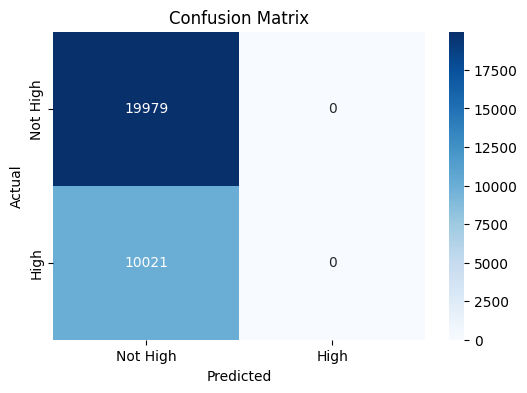

Confusion Matrix Values:
[[19979     0]
 [10021     0]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix generate
cm = confusion_matrix(y_test, y_test_pred)

# Heatmap ke zariye visualize 
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not High', 'High'], 
            yticklabels=['Not High', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix Values:")
print(cm)

ROC-AUC Analysis 
a. Plot the ROC curve and calculate the AUC score. What does this tell you about model 
discriminative ability? 

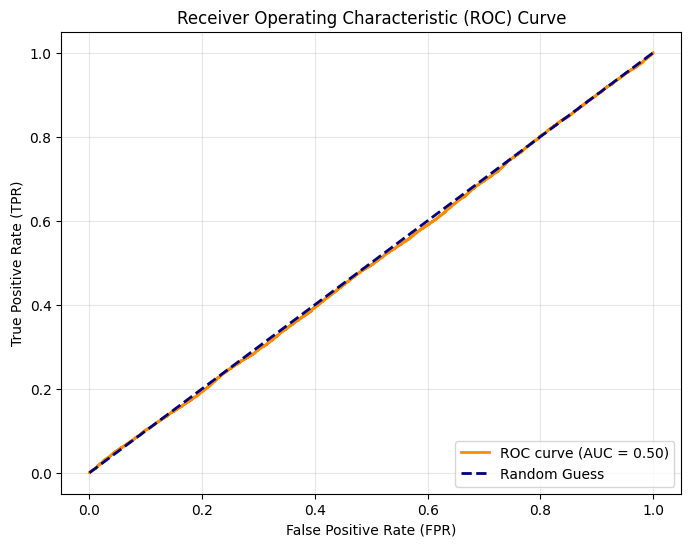

Area Under the Curve (AUC): 0.4964


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Class probabilities (sirf positive class '1' ke liye)
y_probs = log_model.predict_proba(X_test)[:, 1]

# 2. ROC curve ke points calculate 
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. AUC score calculate 
auc_score = roc_auc_score(y_test, y_probs)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Area Under the Curve (AUC): {auc_score:.4f}")

Classification Report Analysis 
Provide and interpret the classification report. Which class (high_burnout = 0 or 1) is the model 
better at predicting? Why might this be happening? 

In [ ]:
from sklearn.metrics import classification_report

# Classification report generate 
report = classification_report(y_test, y_test_pred, target_names=['Normal/Medium (0)', 'High Burnout (1)'])

print("--- Classification Report ---")
print(report)

--- Classification Report ---
                   precision    recall  f1-score   support

Normal/Medium (0)       0.67      1.00      0.80     19979
 High Burnout (1)       0.00      0.00      0.00     10021

         accuracy                           0.67     30000
        macro avg       0.33      0.50      0.40     30000
     weighted avg       0.44      0.67      0.53     30000



c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aqib farooq\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

**Section 6: Model Interpretation & Critical Thinking **


a. Extract and interpret the coefficients of the logistic regression model. Which features have the 
strongest positive and negative influence on predicting high burnout? 
b. How would you explain the impact of academic_pressure_score on burnout odds to a 
non-technical stakeholder? 

In [ ]:
import pandas as pd
import numpy as np

# 1. Coefficients aur Feature Names extract
intercept = log_model.intercept_[0]
coefficients = log_model.coef_[0]
features = X.columns

#ak dataframe good to see
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

print("--- Model Coefficients ---")
print(coeff_df)

# 3. Odds Ratio nikalne ke liye (Exponential of coefficients)
coeff_df['Odds_Ratio'] = np.exp(coeff_df['Coefficient'])
print("\n--- Odds Ratios ---")
print(coeff_df[['Feature', 'Odds_Ratio']])

--- Model Coefficients ---
                    Feature   Coefficient
21       sleep_quality_Poor  1.106096e-02
7   academic_pressure_score  2.133273e-03
22    internet_quality_Good  1.378620e-03
0                student_id -3.308367e-07
6          depression_score -8.069221e-04
15                 year_2nd -9.530360e-04
8    financial_stress_score -1.372216e-03
11    attendance_percentage -1.530926e-03
9      social_support_score -2.048188e-03
5             anxiety_score -2.564479e-03
2         daily_study_hours -2.696483e-03
4         screen_time_hours -3.376071e-03
14             gender_Other -4.734539e-03
16                 year_3rd -6.370760e-03
20       sleep_quality_Good -8.764085e-03
17                 year_4th -8.830769e-03
12                     cgpa -9.374516e-03
1                       age -1.012123e-02
18         stress_level_Low -1.062842e-02
19      stress_level_Medium -1.592056e-02
3         daily_sleep_hours -1.667190e-02
13              gender_Male -1.855250e-02
23    i